In [1]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib


import sys
sys.path.append('..')
import plot_settings
plot_settings.apply()

import sim_PyBaMM
importlib.reload(sim_PyBaMM);


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [98]:
# -----------------------------
# 0) Load I/V data
# -----------------------------

def get_vals(T):
    '''
    Run the PyBaMM model and extract the current, voltage, and concentration
    '''
    sol, model,  param = sim_PyBaMM.simulate_GRF();
    t = np.linspace(0, sol['Time [s]'].entries[-1], T)
    I = sol.observe(model.variables['Current [A]'])(t)
    V = sol.observe(model.variables['Terminal voltage [V]'])(t)
    cn = sol.observe(model.variables['X-averaged negative particle concentration [mol.m-3]'])(t)[-1, :] # Surface conc.
    cp = sol.observe(model.variables['X-averaged positive particle concentration [mol.m-3]'])(t)[-1, :] # Surface conc.

    # print(param['Nominal cell capacity [A.h]'])
    # print(t[-1])
    return t, V, I, cn, cp

def gen_data_I_c(B, T):
    '''
    B: batch size, T: time steps
    '''
    V = np.zeros((B, T, 1)) # 1 channel
    I = np.zeros((B, T, 1))
    I_dot = np.zeros((B, T, 1))
    cn = np.zeros((B, T, 1))
    cp = np.zeros((B, T, 1))
    cn_dot = np.zeros((B, T, 1))
    cp_dot = np.zeros((B, T, 1))

    for i in trange(B):
        t, V[i, :, 0], I[i, :, 0], cn[i, :, 0], cp[i, :, 0] = get_vals(T)
        
        I[i, 0, 0] = 0  # Set initial current to zero for consistency

        # dt = t[1] - t[0]  # Assuming uniform time steps
        dt = 1  # Override dt to 1 step for simplicity --> cn_dot = cn_delta
        # cn_dot[i, 0, :] = np.gradient(cn[i, 0, :], dt)

        cn_dot[:, :-1] = np.diff(cn, axis=1)
        cp_dot[:, :-1] = np.diff(cp, axis=1)
        I_dot[:, 1:] = np.diff(I, axis=1) # Backward difference, first time step is zero
        I_dot[:, 0] = I_dot[:,1]  # Set initial I_dot to zero

        cn_dot[:, -1] = cn_dot[:, -2]  # Pad last time step with second to last value
        cp_dot[:, -1] = cp_dot[:, -2]  # Pad last time

    return I, I_dot, V, cn, cn_dot, cp, cp_dot

# I, I_dot, V, cn, cn_dot, cp, cp_dot = gen_data_I_c(1, 1000)
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
# ax1.plot(I[0, :, 0], label='I')
# ax2.plot(I_dot[0, :, 0], label='I_dot')
# print(I[0, :10, 0])

In [2]:
sol, model, param = sim_PyBaMM.simulate_GRF();
cn_max = param['Maximum concentration in negative electrode [mol.m-3]']
cp_max = param['Maximum concentration in positive electrode [mol.m-3]']
print(cn_max, cp_max)

24983.2619938437 51217.9257309275


In [3]:
''' Generate data '''
B = 400
T = int(sol['Time [s]'].entries[-1]) # Use the original time steps from PyBaMM solution

print(T)

B1 = 100
T1 = 5000
#I, I_dot, V, cn, cn_dot, cp, cp_dot = gen_data_I_c(B1, T1)
#np.savez('GRF_data_c_dot_fine.npz', I=I, I_dot=I_dot, V=V, cn=cn, cn_dot=cn_dot, cp=cp, cp_dot=cp_dot)

3600


In [4]:
#I = np.load('GRF_data_c_dot.npz')['I']
#I_dot = np.load('GRF_data_c_dot.npz')['I_dot']
#V = np.load('GRF_data_c_dot.npz')['V']
#cn = np.load('GRF_data_c_dot.npz')['cn']
#cn_dot = np.load('GRF_data_c_dot.npz')['cn_dot']
#cp = np.load('GRF_data_c_dot.npz')['cp']
#cp_dot = np.load('GRF_data_c_dot.npz')['cp_dot']
I = np.load('GRF_data_c_dot_fine.npz')['I']
I_dot = np.load('GRF_data_c_dot_fine.npz')['I_dot']
V = np.load('GRF_data_c_dot_fine.npz')['V']
cn = np.load('GRF_data_c_dot_fine.npz')['cn']
cn_dot = np.load('GRF_data_c_dot_fine.npz')['cn_dot']
cp = np.load('GRF_data_c_dot_fine.npz')['cp']
cp_dot = np.load('GRF_data_c_dot_fine.npz')['cp_dot']

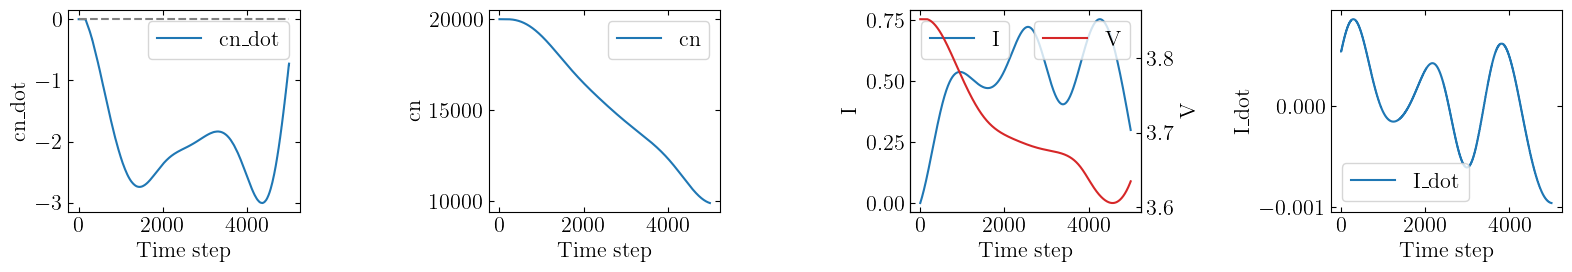

In [5]:
idb = 2

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 3))
ax1.plot(cn_dot[idb, :, 0], label='cn_dot')
ax1.hlines(0, 0, len(cn_dot[idb,:,0]), colors='gray', linestyles='dashed')
ax1.set_xlabel('Time step')
ax1.set_ylabel('cn_dot')
ax1.legend()

ax2.plot(cn[idb, :, 0], label='cn')
ax2.set_xlabel('Time step')
ax2.set_ylabel('cn')
ax2.legend()

ax3_ = ax3.twinx()
ax3.plot(I[idb, :, 0], label='I')
ax3_.plot(V[idb, :, 0], label='V', color='tab:red')
ax3_.set_ylabel('V')
ax3.set_xlabel('Time step')
ax3.set_ylabel('I')
ax3.legend()
ax3_.legend()

ax4.plot(I_dot[idb, :, 0], label='I_dot')
ax4.set_xlabel('Time step')
ax4.set_ylabel('I_dot')
ax4.legend()
plt.tight_layout()

### Plotting range of the variables


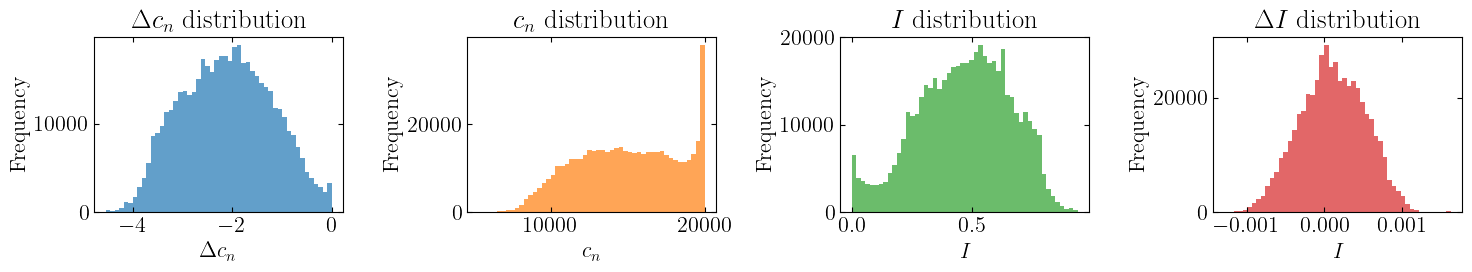

In [6]:
def plot_histograms(cn_dot_train, cn_train, I_train, I_dot_train):
    f, ax = plt.subplots(1, 4, figsize=(15,3 ))

    ax[0].hist(cn_dot_train.flatten(), bins=50, color='tab:blue', alpha=0.7)
    ax[0].set_title('$\\Delta c_n$ distribution')
    ax[0].set_xlabel('$\\Delta c_n$')
    ax[0].set_ylabel('Frequency')   
    ax[1].hist(cn_train.flatten(), bins=50, color='tab:orange', alpha=0.7)
    ax[1].set_title('$c_n$ distribution')
    ax[1].set_xlabel('$c_n$')
    ax[1].set_ylabel('Frequency')
    ax[2].hist(I_train.flatten(), bins=50, color='tab:green', alpha=0.7)
    ax[2].set_title('$I$ distribution')
    ax[2].set_xlabel('$I$')
    ax[2].set_ylabel('Frequency')
    ax[3].hist(I_dot_train.flatten(), bins=50, color='tab:red', alpha=0.7)
    ax[3].set_title('$\\Delta I$ distribution')
    ax[3].set_xlabel('$I$')
    ax[3].set_ylabel('Frequency')
    plt.tight_layout()  
plot_histograms(cn_dot,cn,I,I_dot)

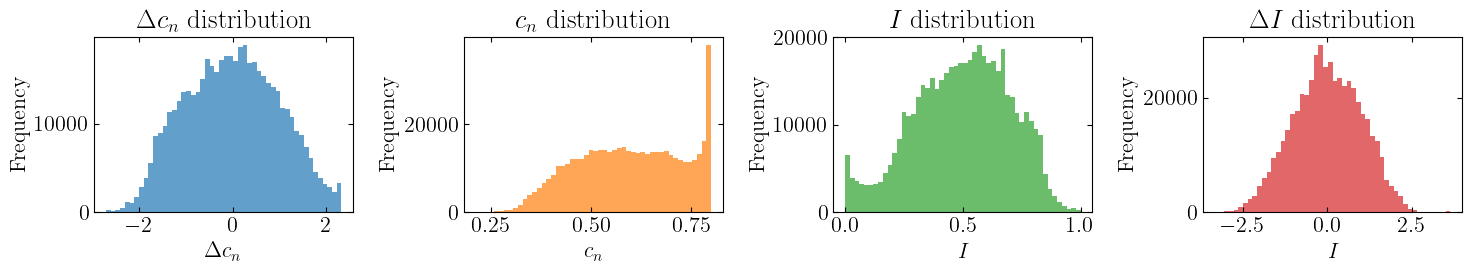

In [7]:
# -----------------------------
# 1) Scaling
# -----------------------------

def scale(data, scaler):
    B, T, C = data.shape
    data_flat = data.reshape(-1, C)  # (B*T, C)

    data_scaled_flat = scaler.fit_transform(data_flat)  # (B*T, C)
    return data_scaled_flat.reshape(B, T, C)  # (B, T, C)

def descale(data_scaled, scaler):
    B, T, C = data_scaled.shape
    data_scaled_flat = data_scaled.reshape(-1, C)  # (B*T, C)

    data_flat = scaler.inverse_transform(data_scaled_flat)  # (B*T, C)
    return data_flat.reshape(B, T, C)  # (B, T, C)

scaler_I = MinMaxScaler()
scaler_I_dot = StandardScaler()
scaler_cn_dot = MinMaxScaler()
scaler_cn = MinMaxScaler()


cn_s = cn / cn_max#scale(cn, scaler_cn)
cn_dot_s = (cn_dot - np.mean(cn_dot))/np.std(cn_dot) #scale(cn_dot, scaler_cn_dot)
I_dot_s = scale(I_dot, scaler_I_dot)
I_s = scale(I, scaler_I)


plot_histograms(cn_dot_s,cn_s,I_s,I_dot_s)


In [8]:
# -----------------------------
# 2) Splitting into train/test
# -----------------------------

test_size = 0.1
split = int(test_size * B)

def split_data(data, split):
    return data[:split], data[split:]

# Split and convert to float32 for PyTorch
I_test, I_train = split_data(I_s, split)
I_dot_test, I_dot_train = split_data(I_dot_s, split)

cn_test, cn_train = split_data(cn_s, split)
cn_dot_test, cn_dot_train = split_data(cn_dot_s, split)

# Convert to PyTorch tensors


train_dataset = TensorDataset(torch.tensor(I_train, dtype=torch.float32),    # Not using scaled
                              torch.from_numpy(I_dot_train).float(), 
                              torch.from_numpy(cn_train).float(), 
                              torch.from_numpy(cn_dot_train).float())




loader = DataLoader(train_dataset, shuffle=True, drop_last=True)

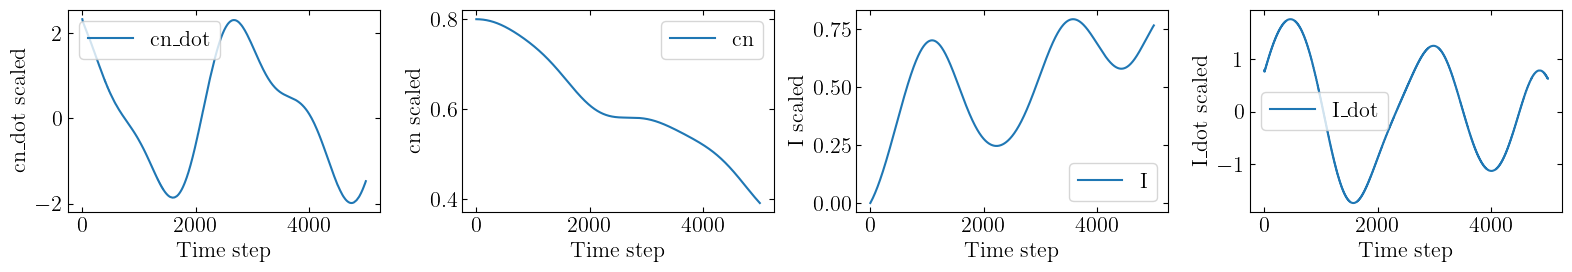

In [17]:
idb = 0

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 3))
ax1.plot(cn_dot_s[idb, :, 0], label='cn_dot')
ax1.set_xlabel('Time step')
ax1.set_ylabel('cn_dot scaled')
ax1.legend()
ax2.plot(cn_s[idb, :, 0], label='cn')
ax2.set_xlabel('Time step')
ax2.set_ylabel('cn scaled')
ax2.legend()
ax3.plot(I_s[idb, :, 0], label='I')
ax3.set_xlabel('Time step')
ax3.set_ylabel('I scaled')
ax3.legend()
ax4.plot(I_dot_s[idb, :, 0], label='I_dot')
ax4.set_xlabel('Time step')
ax4.set_ylabel('I_dot scaled')
ax4.legend()
plt.tight_layout()

In [10]:
# -----------------------------
# 2) Network
# -----------------------------

class Net(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features=3, out_features=hidden_dim), # input i_t, i_dot_t, c_t
            nn.Tanh(),
            nn.Linear(hidden_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1),  # output c_dot_k
        )

    def forward(self, I, I_dot, c):
        # x: [B*T, 1], c: [B*T, 1]
        x = torch.cat([I, I_dot, c], dim=-1)  # [B*T, 3]
        output = self.net(x)
        return output
    
    def compute_l1_loss(self, w):
      return torch.abs(w).sum()

In [11]:
# -----------------------------
# 3) Training loop
# -----------------------------

model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()

def training(epochs=50):
    history = {"loss": []}
    for ep in range(1,epochs+1):
        model.train()
        last = None
        
        for I_batch, I_dot_batch, cn_batch, cn_dot_batch in loader:
            # batch: (B, T, 1) -> (B*T, 1)
            I_flat = I_batch.reshape(-1, 1)
            I_dot_flat = I_dot_batch.reshape(-1, 1)
            cn_flat = cn_batch.reshape(-1, 1)
            y_flat = cn_dot_batch.reshape(-1, 1)
            
            # predict parameters
            cn_dot_hat = model(I_flat, I_dot_flat, cn_flat)
            loss = mse(cn_dot_hat, y_flat)
            

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            last = loss.item()

        history["loss"].append(last)
        if epochs > 100:
            if ep % 10 == 0:
                print(f'Epoch {ep} | loss {last} |')    
        else:
            print(f'Epoch {ep} | loss {last} |')

    return history


  

In [12]:
history = training(epochs=250)

Epoch 10 | loss 1.221450686454773 |
Epoch 20 | loss 0.32928287982940674 |
Epoch 30 | loss 1.014817714691162 |
Epoch 40 | loss 0.5379365086555481 |
Epoch 50 | loss 0.3837124705314636 |
Epoch 60 | loss 1.3594249486923218 |
Epoch 70 | loss 0.6914547681808472 |
Epoch 80 | loss 0.7485889792442322 |
Epoch 90 | loss 0.6920555830001831 |
Epoch 100 | loss 1.842403531074524 |
Epoch 110 | loss 0.577016294002533 |
Epoch 120 | loss 0.9277493953704834 |
Epoch 130 | loss 0.5382524132728577 |
Epoch 140 | loss 1.0170100927352905 |
Epoch 150 | loss 0.4372463822364807 |
Epoch 160 | loss 0.5661215782165527 |
Epoch 170 | loss 0.8760225772857666 |
Epoch 180 | loss 0.5012539029121399 |
Epoch 190 | loss 1.1026700735092163 |
Epoch 200 | loss 0.687427818775177 |
Epoch 210 | loss 0.7241993546485901 |
Epoch 220 | loss 0.46725380420684814 |
Epoch 230 | loss 1.515676736831665 |
Epoch 240 | loss 0.6516819596290588 |
Epoch 250 | loss 1.8371835947036743 |


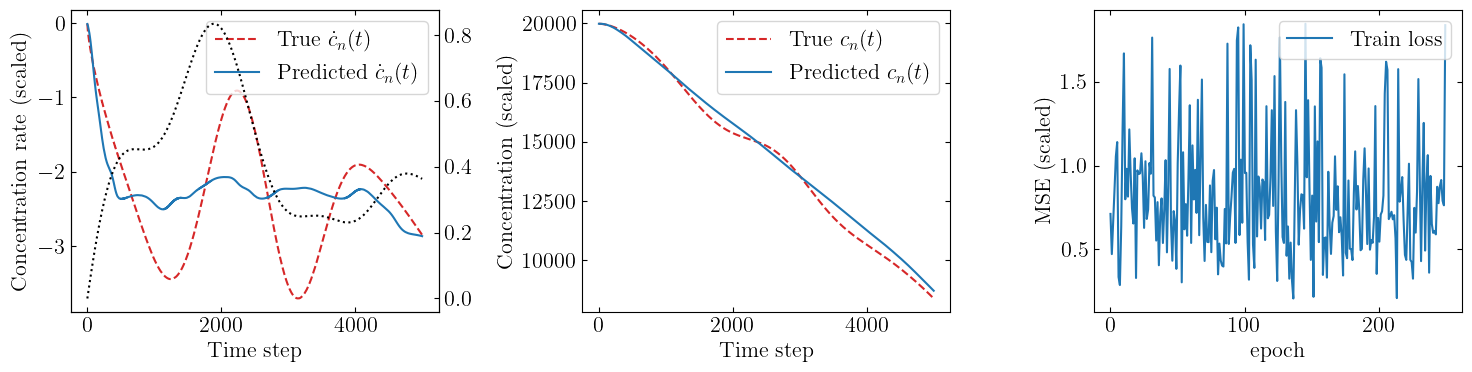

In [19]:
# -----------------------------
# 4) Test + plot
# -----------------------------
''' Predicted on known cn, not using Euler to step forward '''
model.eval()
idx = 10

cn_dot_hat_list = []
cn_euler = np.zeros_like(cn_test)  # (B, T, 1)
cn_t = torch.tensor([[cn_test[idx, 0, 0]]], dtype=torch.float32).item()
cn_euler[idx, 0, 0] = cn_t * cn_max # Descale initial cn to original scale for Euler stepping

dt = 1

def step(idx, t, cn_dot_hat, dt=dt):
    # Euler step: c_{k+1} = c_k + c_dot_k * dt
    cn_euler[idx, t+1, 0] = cn_euler[idx, t, 0] + cn_dot_hat * dt
    # cn_euler[idx, t+1, 0] = torch.clamp(torch.tensor(cn_euler[idx, t+1, 0]), min=0.3, max=1.5)

for t in range(5000):
    I_t  = torch.tensor([[I_test[idx, t, 0]]], dtype=torch.float32)   # (1,1)
    I_dot_t = torch.tensor([[I_dot_test[idx, t, 0]]], dtype=torch.float32)   # (1,1)
    cn_t = torch.tensor([[cn_test[idx, t, 0]]], dtype=torch.float32)  # (1,1)

    with torch.no_grad():
        cn_dot_hat = model(I_t, I_dot_t, cn_t).item()*np.std(cn_dot) + np.mean(cn_dot) # Descale prediction to original scale


    cn_dot_hat_list.append(cn_dot_hat)
    if t < 5000 -1:  # Avoid stepping beyond the last time step
        step(idx, t, cn_dot_hat)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

ax1_ = ax1.twinx()

ax1.plot(cn_dot_test[idx, :, 0]*np.std(cn_dot) + np.mean(cn_dot), color="tab:red", linestyle="dashed", label="True $\\dot{c}_n(t)$")
ax1.plot(cn_dot_hat_list, color="tab:blue", label="Predicted $\\dot{c}_n(t)$")
ax1_.plot(I_test[idx, :, 0], label='I', color='black', linestyle='dotted')
ax1.set_xlabel("Time step")
ax1.set_ylabel("Concentration rate (scaled)")
ax1.legend()

ax2.plot(cn_test[idx, :, 0] * cn_max, color="tab:red", linestyle="dashed", label="True $c_n(t)$")
ax2.plot(cn_euler[idx, :, 0], color="tab:blue", label="Predicted $c_n(t)$")
ax2.set_xlabel("Time step")
ax2.set_ylabel("Concentration (scaled)")
ax2.legend()

ax3.plot(history["loss"], label="Train loss")
ax3.set_xlabel("epoch")
ax3.set_ylabel("MSE (scaled)")
ax3.legend()

plt.tight_layout()

Initial cn: 0.8000
0.0 0.39106781164991306


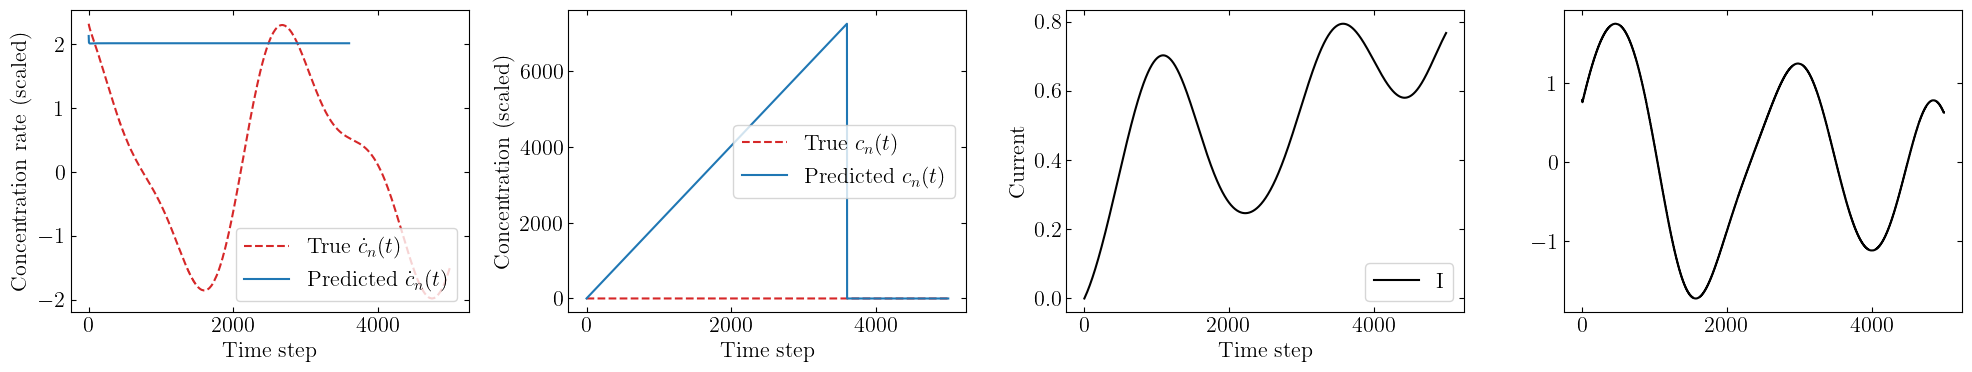

In [123]:
# -----------------------------
# 5) Predict from euler forward 
# -----------------------------
model.eval()
idx = 0

cn_euler = np.zeros_like(cn_test)  # (B, T, 1)

''' Using true initial cn, then forward Euler '''
cn_0 = torch.tensor([[cn_test[idx, 0, 0]]], dtype=torch.float32).item()
cn_euler[idx, 0, 0] = cn_0
print(f"Initial cn: {cn_0:.4f}")

cn_dot_hat_list = []
# dt = t_tot / T  # Total time divided by number of steps, assuming uniform spacing
dt = 1


def step(idx, t, I_t, I_dot, cn_t):
    # Predict cn_dot from current I_t and concentration cn_t
    with torch.no_grad():
            cn_dot_hat_s = model(I_t, I_dot, cn_t).item()    # pick item from output tensor

    cn_euler[idx, t+1, 0] = cn_euler[idx, t, 0] + cn_dot_hat_s * dt   # Euler step: c_{k+1} = c_k + c_dot_k * dt
    return cn_dot_hat_s


for t in range(T):
    I_t  = torch.tensor([[I_test[idx, t, 0]]], dtype=torch.float32)   # (1,1)
    I_dot_t = torch.tensor([[I_dot_test[idx, t, 0]]], dtype=torch.float32)   # (1,1)

    if t == 0:
        # Predict on initial concentration, then use Euler to step forward
        cn_t = torch.tensor([[cn_test[idx, t, 0]]], dtype=torch.float32)  # (1,1)
        cn_dot_hat = step(idx, t, I_t, I_dot_t, cn_t)
    elif t < T-1:
        cn_t = torch.tensor([[cn_euler[idx, t, 0]]], dtype=torch.float32)  # (1,1)
        cn_dot_hat = step(idx, t, I_t, I_dot_t, cn_t)

    cn_dot_hat_list.append(cn_dot_hat)
    # print(f"True cn_dot: {cn_dot_test_s[idx, t, 0]:.4f} | Predicted cn_dot: {cn_dot_hat:.4f}")

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 4))

ax1.plot(cn_dot_test[idx, :, 0],  color="tab:red", linestyle="dashed", label="True $\\dot{c}_n(t)$")
ax1.plot(cn_dot_hat_list, color="tab:blue", label="Predicted $\\dot{c}_n(t)$")
ax1.set_xlabel("Time step")
ax1.set_ylabel("Concentration rate (scaled)")
ax1.legend()

ax2.plot(cn_test[idx, :, 0], color="tab:red", linestyle="dashed", label="True $c_n(t)$")
ax2.plot(cn_euler[idx, :, 0], color="tab:blue", label="Predicted $c_n(t)$")
ax2.set_xlabel("Time step")
ax2.set_ylabel("Concentration (scaled)")
ax2.legend()

ax3.plot(I_test[idx, :, 0], label='I', color='black')
ax3.set_xlabel("Time step")
ax3.set_ylabel("Current")
ax3.legend()

ax4.plot(I_dot_test[idx, :, 0], label='I_dot', color='black')
plt.tight_layout()

# plt.savefig('figs/2_JN_PENN_ECM.pdf')

print(cn_euler[idx, -1, 0], cn_test[idx, -1, 0])